In [2]:
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import numpy as np
import seaborn as sns
from prophet.diagnostics import cross_validation, performance_metrics
import itertools

In [3]:
df = pd.read_parquet('../data/processed/preprocessed_prophet.parquet')
df.dropna(inplace = True)
df.head()

,mempool_blocks_blockSize,mempool_blocks_blockVSize,mempool_blocks_nTx,mempool_blocks_totalFees,mempool_blocks_medianFee,recommended_fee_fastestFee,recommended_fee_halfHourFee,recommended_fee_hourFee,recommended_fee_economyFee,recommended_fee_minimumFee,...,mempool_fee_histogram_bin_70_75,mempool_fee_histogram_bin_75_80,mempool_fee_histogram_bin_80_85,mempool_fee_histogram_bin_85_90,mempool_fee_histogram_bin_90_95,mempool_fee_histogram_bin_95_100,mempool_fee_histogram_bin_100_150,mempool_fee_histogram_bin_150_200,mempool_fee_histogram_bin_200_250,mempool_fee_histogram_bin_250_300
timestamp,,,,,,,,,,,,,,,,,,,,,
2025-03-05 02:00:00,2.131827e+06,997874.250000,1030.000000,2.077770e+06,1.300139,2.000000,2.000000,2.000000,2.000000,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-03-05 02:15:00,1.801526e+06,997925.916667,2627.000000,3.407913e+06,2.473960,3.000000,2.666667,2.666667,2.666667,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-03-05 02:30:00,2.055350e+06,997965.916667,922.000000,1.855358e+06,1.355898,2.000000,2.000000,2.000000,2.000000,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-03-05 02:45:00,2.006800e+06,997970.083333,1296.666667,2.167251e+06,1.536092,2.333333,2.333333,2.333333,2.333333,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-03-05 03:00:00,1.773658e+06,997960.333333,2725.333333,3.462741e+06,2.467659,3.333333,3.000000,3.000000,3.000000,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
y = df["recommended_fee_fastestFee"]
X = df.drop(columns = "recommended_fee_fastestFee")
X = X.reset_index()
X = X.drop(columns = "timestamp")

# last 24h as test
split_index = len(X) - 96

X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

In [5]:
df_prophet = y_train.reset_index()
df_prophet = df_prophet.rename(columns={
    'timestamp': 'ds',
    'recommended_fee_fastestFee': 'y'
})
df_prophet.head()

,ds,y
0,2025-03-05 02:00:00,2.000000
1,2025-03-05 02:15:00,3.000000
2,2025-03-05 02:30:00,2.000000
3,2025-03-05 02:45:00,2.333333
4,2025-03-05 03:00:00,3.333333


In [6]:
model = Prophet(
    daily_seasonality=False,
    weekly_seasonality=False
)
model.add_seasonality(name='hourly', period=1/24, fourier_order=5) # 每小时重复（注意 period 是 1/24）
model.add_seasonality(name='hourly', period=1, fourier_order=10)  # 每小时周期
model.add_seasonality(name='daily', period=24, fourier_order=5)  # 每日周期

In [7]:
param_grid = {  
    'changepoint_prior_scale': [0.001, 0.01, 0.1, 0.5],
    'seasonality_prior_scale': [1.0, 10.0, 20.0],
    'seasonality_mode': ['additive', 'multiplicative']
}

In [11]:
# 创建参数组合
all_params = [dict(zip(param_grid.keys(), v)) for v in itertools.product(*param_grid.values())]

results = []  # 存放每组评估结果

for params in all_params:
    m = Prophet(
        daily_seasonality=False,
        weekly_seasonality=False,
        **params
    )
    m.add_seasonality(name='hourly', period=1/24, fourier_order=6)
    m.add_seasonality(name='daily', period=1, fourier_order=8)
    m.add_seasonality(name='weekly', period=7, fourier_order=4)
    
    m.fit(df_prophet)
    df_cv = cross_validation(m, initial='7 days', period='1 day', horizon='1 day', parallel="processes")
    df_p = performance_metrics(df_cv)
    
    results.append((params, df_p['rmse'].mean()))
print("Done")

16:35:40 - cmdstanpy - INFO - Chain [1] start processing
16:35:40 - cmdstanpy - INFO - Chain [1] done processing
16:35:42 - cmdstanpy - INFO - Chain [1] start processing
16:35:42 - cmdstanpy - INFO - Chain [1] start processing
16:35:42 - cmdstanpy - INFO - Chain [1] start processing
16:35:42 - cmdstanpy - INFO - Chain [1] start processing
16:35:42 - cmdstanpy - INFO - Chain [1] start processing
16:35:42 - cmdstanpy - INFO - Chain [1] start processing
16:35:42 - cmdstanpy - INFO - Chain [1] start processing
16:35:42 - cmdstanpy - INFO - Chain [1] start processing
16:35:42 - cmdstanpy - INFO - Chain [1] start processing
16:35:42 - cmdstanpy - INFO - Chain [1] start processing
16:35:42 - cmdstanpy - INFO - Chain [1] done processing
16:35:42 - cmdstanpy - INFO - Chain [1] done processing
16:35:42 - cmdstanpy - INFO - Chain [1] done processing
16:35:42 - cmdstanpy - INFO - Chain [1] done processing
16:35:42 - cmdstanpy - INFO - Chain [1] done processing
16:35:42 - cmdstanpy - INFO - Chain [

Done


16:35:43 - cmdstanpy - INFO - Chain [1] done processing
16:35:44 - cmdstanpy - INFO - Chain [1] start processing
16:35:44 - cmdstanpy - INFO - Chain [1] done processing
16:35:44 - cmdstanpy - INFO - Chain [1] start processing
16:35:44 - cmdstanpy - INFO - Chain [1] start processing
16:35:44 - cmdstanpy - INFO - Chain [1] start processing
16:35:44 - cmdstanpy - INFO - Chain [1] start processing
16:35:44 - cmdstanpy - INFO - Chain [1] start processing
16:35:44 - cmdstanpy - INFO - Chain [1] done processing
16:35:44 - cmdstanpy - INFO - Chain [1] done processing
16:35:44 - cmdstanpy - INFO - Chain [1] done processing
16:35:44 - cmdstanpy - INFO - Chain [1] done processing
16:35:44 - cmdstanpy - INFO - Chain [1] start processing
16:35:44 - cmdstanpy - INFO - Chain [1] start processing
16:35:44 - cmdstanpy - INFO - Chain [1] done processing
16:35:44 - cmdstanpy - INFO - Chain [1] start processing
16:35:44 - cmdstanpy - INFO - Chain [1] start processing
16:35:44 - cmdstanpy - INFO - Chain [1

Done


16:35:45 - cmdstanpy - INFO - Chain [1] done processing
16:35:46 - cmdstanpy - INFO - Chain [1] start processing
16:35:46 - cmdstanpy - INFO - Chain [1] done processing
16:35:46 - cmdstanpy - INFO - Chain [1] start processing
16:35:46 - cmdstanpy - INFO - Chain [1] start processing
16:35:46 - cmdstanpy - INFO - Chain [1] start processing
16:35:46 - cmdstanpy - INFO - Chain [1] start processing
16:35:46 - cmdstanpy - INFO - Chain [1] start processing
16:35:46 - cmdstanpy - INFO - Chain [1] done processing
16:35:46 - cmdstanpy - INFO - Chain [1] done processing
16:35:46 - cmdstanpy - INFO - Chain [1] start processing
16:35:46 - cmdstanpy - INFO - Chain [1] start processing
16:35:46 - cmdstanpy - INFO - Chain [1] done processing
16:35:46 - cmdstanpy - INFO - Chain [1] start processing
16:35:46 - cmdstanpy - INFO - Chain [1] done processing
16:35:46 - cmdstanpy - INFO - Chain [1] done processing
16:35:46 - cmdstanpy - INFO - Chain [1] start processing
16:35:46 - cmdstanpy - INFO - Chain [1

...

16:37:20 - cmdstanpy - INFO - Chain [1] done processing
16:37:21 - cmdstanpy - INFO - Chain [1] start processing
16:37:21 - cmdstanpy - INFO - Chain [1] start processing
16:37:21 - cmdstanpy - INFO - Chain [1] start processing
16:37:21 - cmdstanpy - INFO - Chain [1] start processing
16:37:21 - cmdstanpy - INFO - Chain [1] start processing
16:37:21 - cmdstanpy - INFO - Chain [1] start processing
16:37:21 - cmdstanpy - INFO - Chain [1] done processing
16:37:21 - cmdstanpy - INFO - Chain [1] start processing
16:37:21 - cmdstanpy - INFO - Chain [1] start processing
16:37:21 - cmdstanpy - INFO - Chain [1] start processing
16:37:21 - cmdstanpy - INFO - Chain [1] start processing
16:37:21 - cmdstanpy - INFO - Chain [1] done processing
16:37:21 - cmdstanpy - INFO - Chain [1] start processing
16:37:21 - cmdstanpy - INFO - Chain [1] done processing
16:37:21 - cmdstanpy - INFO - Chain [1] start processing
16:37:21 - cmdstanpy - INFO - Chain [1] done processing
16:37:21 - cmdstanpy - INFO - Chain 

Done


16:37:26 - cmdstanpy - INFO - Chain [1] done processing
16:37:27 - cmdstanpy - INFO - Chain [1] start processing
16:37:27 - cmdstanpy - INFO - Chain [1] start processing
16:37:27 - cmdstanpy - INFO - Chain [1] start processing
16:37:27 - cmdstanpy - INFO - Chain [1] start processing
16:37:27 - cmdstanpy - INFO - Chain [1] start processing
16:37:27 - cmdstanpy - INFO - Chain [1] start processing
16:37:27 - cmdstanpy - INFO - Chain [1] start processing
16:37:28 - cmdstanpy - INFO - Chain [1] start processing
16:37:28 - cmdstanpy - INFO - Chain [1] start processing
16:37:28 - cmdstanpy - INFO - Chain [1] start processing
16:37:28 - cmdstanpy - INFO - Chain [1] done processing
16:37:28 - cmdstanpy - INFO - Chain [1] start processing
16:37:28 - cmdstanpy - INFO - Chain [1] done processing
16:37:28 - cmdstanpy - INFO - Chain [1] done processing
16:37:28 - cmdstanpy - INFO - Chain [1] start processing
16:37:28 - cmdstanpy - INFO - Chain [1] done processing
16:37:28 - cmdstanpy - INFO - Chain 

Done


16:37:34 - cmdstanpy - INFO - Chain [1] done processing
16:37:34 - cmdstanpy - INFO - Chain [1] done processing
16:37:34 - cmdstanpy - INFO - Chain [1] done processing


In [12]:
best_params = sorted(results, key=lambda x: x[1])[0]
print(f"最优参数组合：{best_params[0]}\n对应RMSE：{best_params[1]:.4f}")

最优参数组合：{'changepoint_prior_scale': 0.001, 'seasonality_prior_scale': 10.0, 'seasonality_mode': 'additive'}
对应RMSE：2.3800


In [13]:
model = Prophet(
    daily_seasonality=False,
    weekly_seasonality=False,
    changepoint_prior_scale = 0.001,
    seasonality_prior_scale=10.0,
    seasonality_mode='additive'
)
model.add_seasonality(name='hourly', period=1/24, fourier_order=5) # 每小时重复（注意 period 是 1/24）
model.add_seasonality(name='hourly', period=1, fourier_order=10)  # 每小时周期
model.add_seasonality(name='daily', period=24, fourier_order=5)  # 每日周期

In [14]:
model.fit(df_prophet)

16:39:37 - cmdstanpy - INFO - Chain [1] start processing
16:39:37 - cmdstanpy - INFO - Chain [1] done processing


In [15]:
future = model.make_future_dataframe(periods=96, freq='15min')

In [16]:
forecast = model.predict(future)

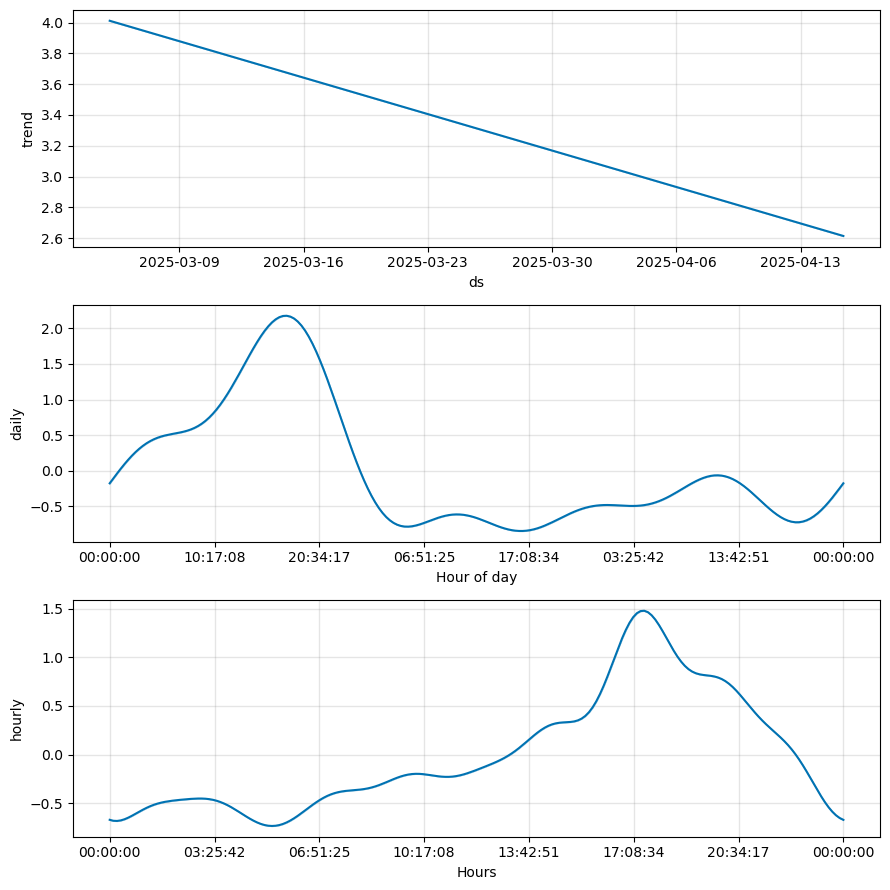

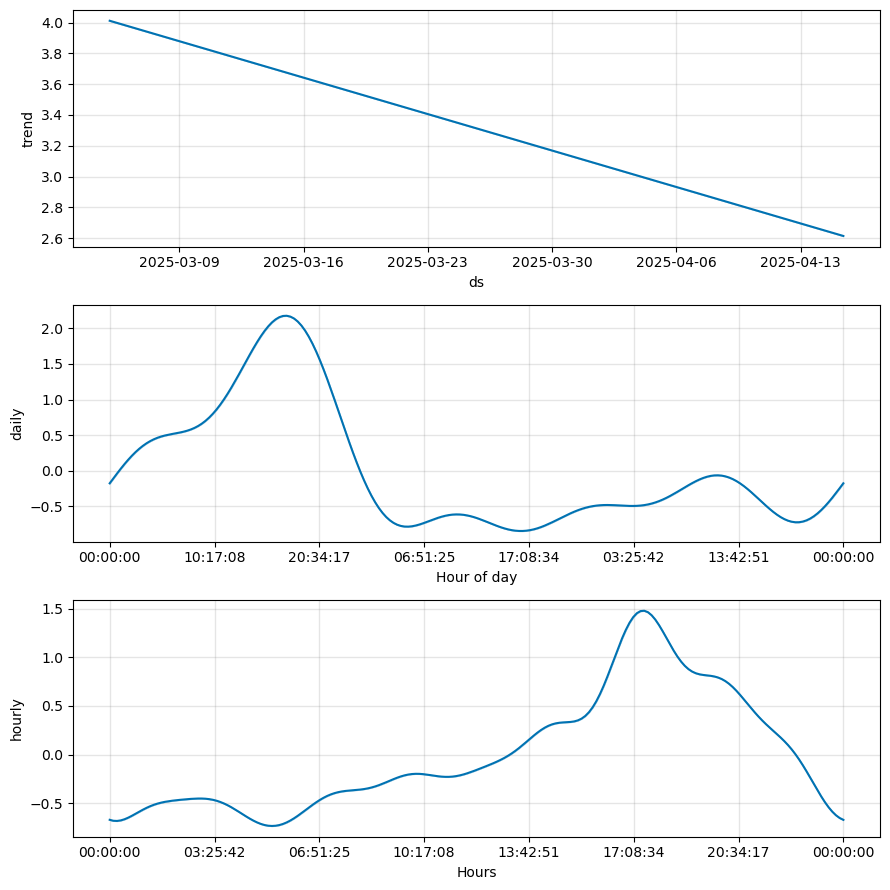

In [17]:
model.plot_components(forecast)

In [18]:
forecast.index = y.index

In [19]:
y_pred = forecast.iloc[-96:]
y_pred = y_pred["yhat"]

In [20]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = mean_absolute_percentage_error(y_test, y_pred)
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.4f}")

MAE: 1.2382
RMSE: 1.4792
MAPE: 0.7028


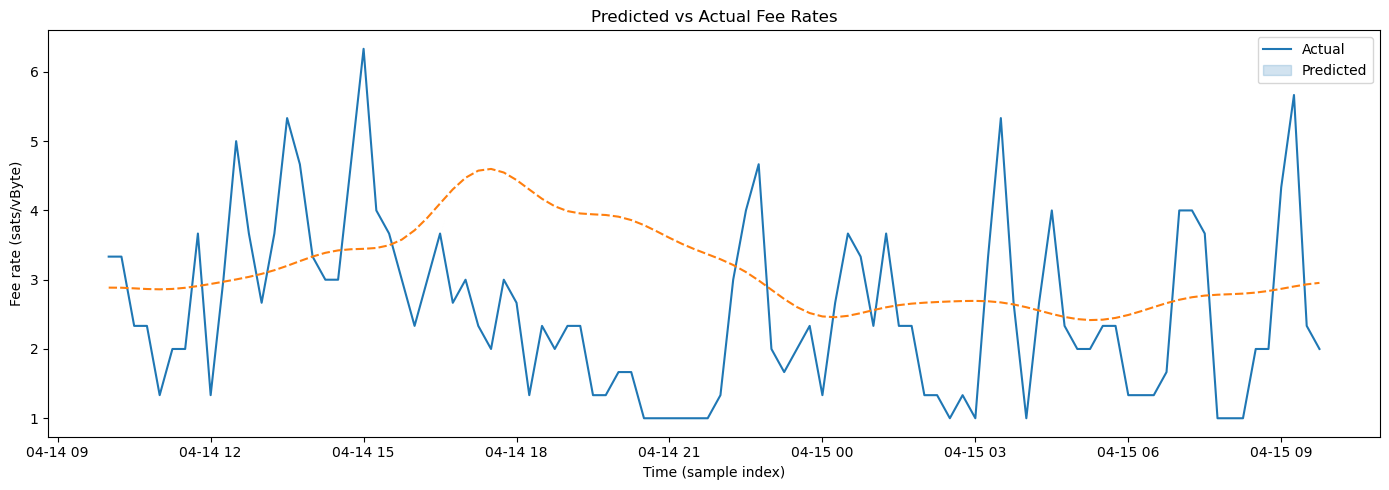

In [21]:
result_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
}, index=y_test.index)

plt.figure(figsize=(14, 5))
sns.lineplot(data=result_df)
plt.title('Predicted vs Actual Fee Rates')
plt.xlabel('Time (sample index)')
plt.ylabel('Fee rate (sats/vByte)')
plt.legend(['Actual', 'Predicted'])
plt.tight_layout()
plt.show()

In [ ]:
df_cv = cross_validation(model, initial='7 days', period='1 day', horizon='1 day')
performance_metrics(df_cv)